In [57]:
import pandas as pd 
import numpy as np 

resultats = pd.read_csv("resultats_extraits_adj_g3.csv")
preferences = pd.read_csv("preference_resultats_mistral_7b_800.csv")

In [58]:
resultats.head()

,Unnamed: 0,panelist_id,preference,adj_orange,adj_bouygues
0,1,67b0d135d362f5886c2e5cfe,J'ai préféré celle de Bouygues. Elle était plu...,"banale, marquant, direct, positif","Marrante, originale, sympa, absurde, différent..."
1,2,67b0d12ed362f5886c2e5b9c,Hmm... difficile. J'ai bien aimé les deux pour...,"Bien, diffus, connu, fiable, clair","Original, fort, créatif, marrant, fiable, clair"
2,3,67b0d12bd362f5886c2e5b09,"J'ai trouvé la pub Bouygues très drôle, mais j...","simple, original, bien, fiable, clair, direct,...","drôle, bizarre, originale, positif, amusante, ..."
3,4,67b0d127d362f5886c2e5a4a,"Je préfère celle d'Orange, sans hésiter. Elle ...","simple, directe, fiable, positive, clairement","plus marquante, bizarre, différente, sûr"
4,5,67b0d12cd362f5886c2e5b4a,Je préfère celle de Bouygues. Pour l'originali...,"bien, passe-partout, efficace, fiable, bonne, ...","Créativité, unique, fort, divertissante, spéci..."


In [59]:
preferences.head()

,Unnamed: 0,panelist_id,preference,brand,confidence
0,1,67b0d135d362f5886c2e5cfe,J'ai préféré celle de Bouygues. Elle était plu...,Bouygues Telecom,1.00
1,2,67b0d12ed362f5886c2e5b9c,Hmm... difficile. J'ai bien aimé les deux pour...,Bouygues,1.00
2,3,67b0d12bd362f5886c2e5b09,"J'ai trouvé la pub Bouygues très drôle, mais j...",Orange,1.00
3,4,67b0d127d362f5886c2e5a4a,"Je préfère celle d'Orange, sans hésiter. Elle ...",Orange,1.00
4,5,67b0d12cd362f5886c2e5b4a,Je préfère celle de Bouygues. Pour l'originali...,Bouygues,0.95


In [60]:
panel = pd.read_csv("interviews.csv")
panel.head()

,panelist_id,interview_number,timestamp,age,children,csp,education,gender,income_level,location.city_size,...,Q_orange_attractivite_2,Q_orange_resonance_emotionnelle_1,Q_orange_image_1,Q_orange_intention_achat_1,Q_comparaison_1,Q_comparaison_2,Q_comparaison_3,Q_comparaison_4,Q_comparaison_5,Q_comparaison_6
0,67b0d135d362f5886c2e5cfe,1,2025-11-15T21:16:58.828353,28,NaN,Ouvriers,Secondary,Male,22000,Large city,...,C'est un peu un enchaînement de trucs négatifs...,Pas grand-chose de fort. Une sorte d'empathie ...,"Ça donne une image de marque solide, fiable. L...","Oui, parce qu'elle parle de fiabilité. Et au f...",J'ai préféré celle de Bouygues. Elle était plu...,"Celle de Bouygues, sans hésiter. L'idée de la ...",Bouygues. Clairement. Pour son concept. Ils on...,Bouygues. Ça m'a fait rire. C'est une émotion ...,C'est marrant parce que même si j'ai préféré l...,Je dirais Orange. Leur promesse c'est 'la fiab...
1,67b0d12ed362f5886c2e5b9c,2,2025-11-15T21:17:04.626005,23,NaN,Employés,Secondary,Male,15000,Small village,...,"Non, pas de point négatif. C'est une bonne pub...",Un sentiment de... familiarité. De l'empathie ...,Ça renforce l'image d'Orange comme une marque ...,"Oui, aussi. Le message 'la fibre la plus fiabl...",Hmm... difficile. J'ai bien aimé les deux pour...,"Celle de Bouygues, je pense. L'idée de la 'pol...","Bouygues, sans aucune hésitation. Pour tout le...",Bouygues m'a fait plus rire. Donc si on parle ...,"Alors là, c'est marrant, mais je dirais peut-ê...",Je dirais Orange. Leur promesse c'est la fiabi...
2,67b0d12bd362f5886c2e5b09,3,2025-11-15T21:17:09.971836,47,"17, 14, 11",Ouvriers,Secondary,Male,27000,Small village,...,"Ça va très vite, on passe d'une scène à l'autr...","De la sympathie, je dirais. On se reconnaît da...",Ça confirme l'image que j'ai d'Orange. C'est l...,"Oui, un peu plus que l'autre. Parce qu'ils ins...","J'ai trouvé la pub Bouygues très drôle, mais j...",Celle de Bouygues. Parce que l'histoire est te...,"Bouygues, sans aucune hésitation. L'idée de l'...","Hmm... 'fortes', aucune des deux. Mais Bouygue...",Plutôt Orange. Parce qu'elle met le doigt sur ...,Je dirais Orange. Le message 'la fibre la plus...
3,67b0d127d362f5886c2e5a4a,4,2025-11-15T21:17:18.211898,68,"38, 35",Retraités,No formal education,Male,21000,Small village,...,"Bon, les jeunes avec leur histoire de banane, ...",Un sentiment de... fiabilité. On se dit 'ah ou...,Une image solide. Quelqu'un sur qui on peut co...,"Oui, ça, ça parle plus. 'La fibre la plus fiab...","Je préfère celle d'Orange, sans hésiter. Elle ...",Celle de Bouygues est peut-être plus marquante...,"Celle de Bouygues sort plus du lot, c'est sûr....","Celle d'Orange, elle m'a rassuré. C'est une ém...","Celle d'Orange, clairement. Elle parle de fiab...","Orange, encore. Ils montrent que ça marche bie..."
4,67b0d12cd362f5886c2e5b4a,5,2025-11-15T21:17:17.641665,29,NaN,Cadres (y compris commerçants & artisans),Higher education,Female,45000,Large city,...,Moins plu... disons que c'est moins surprenant...,"Un sentiment de... réconfort, de réassurance. ...","Ça renforce leur image de leader, de valeur sû...","Oui, parce qu'elle appuie sur un point crucial...",Je préfère celle de Bouygues. Pour l'originali...,"Bouygues, sans hésiter. Le concept de 'scène d...","Encore une fois, Bouygues. Pour son parti pris...",Ça dépend de ce qu'on appelle 'fort'. Bouygues...,C'est difficile... Bouygues m'intrigue sur une...,Orange illustre mieux la promesse globale de '...


In [61]:
panel.columns

Index(['panelist_id', 'interview_number', 'timestamp', 'age', 'children',
       'csp', 'education', 'gender', 'income_level', 'location.city_size',
       'location.country', 'location.household_type',
       'location.mobility_access', 'location.region',
       'location.urban_rural_classification', 'marital_status', 'name',
       'psychographic_attributes',
       'psychographic_attributes.interests_hobbies',
       'psychographic_attributes.lifestyle',
       'psychographic_attributes.motivations',
       'psychographic_attributes.personality_traits',
       'psychographic_attributes.risk_tolerance',
       'psychographic_attributes.values_beliefs', 'tokens_used',
       'duration_seconds', 'Q_bouygues_reactions_spontanees_1',
       'Q_bouygues_memorisation_1', 'Q_bouygues_caractere_distinctif_1',
       'Q_bouygues_attractivite_1', 'Q_bouygues_attractivite_2',
       'Q_bouygues_resonance_emotionnelle_1', 'Q_bouygues_image_1',
       'Q_bouygues_intention_achat_1', 'Q_orange_rea

In [62]:

resultats["adj_orange_list"] = resultats["adj_orange"].str.lower().str.split(r"\s*,\s*")
resultats["adj_bouygues_list"] = resultats["adj_bouygues"].str.lower().str.split(r"\s*,\s*")


In [63]:
from collections import Counter

def flatten_lists(series):
    return [x for sub in series.dropna() for x in sub]

orange_tokens = flatten_lists(resultats["adj_orange_list"])
bouygues_tokens = flatten_lists(resultats["adj_bouygues_list"])

orange_counts = Counter(orange_tokens)
bouygues_counts = Counter(bouygues_tokens)

all_adjs = sorted(set(orange_counts.keys()).union(bouygues_counts.keys()))

orange_probs = np.array([orange_counts.get(a, 0) for a in all_adjs], dtype=float)
bouygues_probs = np.array([bouygues_counts.get(a, 0) for a in all_adjs], dtype=float)

orange_probs = orange_probs / orange_probs.sum()
bouygues_probs = bouygues_probs / bouygues_probs.sum()

In [64]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(orange_probs.reshape(1,-1), bouygues_probs.reshape(1,-1))[0,0]
js_div = jensenshannon(orange_probs, bouygues_probs, base=2)
kl_orange_to_bouygues = entropy(orange_probs, bouygues_probs, base=2)
kl_bouygues_to_orange = entropy(bouygues_probs, orange_probs, base=2)
h_orange = entropy(orange_probs, base=2)
h_bouygues = entropy(bouygues_probs, base=2)


In [65]:
def safe_set(x):
    if isinstance(x, float):
        return set()
    return set(x)

def jaccard(a, b):
    a, b = safe_set(a), safe_set(b)
    if not a and not b:
        return np.nan
    return len(a & b) / len(a | b)

def overlap_counts(a, b):
    a, b = safe_set(a), safe_set(b)
    return len(a & b), len(a - b), len(b - a)

resultats["jaccard_orange_bouygues"] = [
    jaccard(a, b) for a, b in zip(resultats["adj_orange_list"], resultats["adj_bouygues_list"])
]

overlap_values = [
    overlap_counts(a, b) for a, b in zip(resultats["adj_orange_list"], resultats["adj_bouygues_list"])
]

resultats["n_overlap"], resultats["n_orange_only"], resultats["n_bouygues_only"] = zip(*overlap_values)


In [66]:
merged = resultats.merge(
    preferences[["panelist_id", "brand", "confidence"]],
    on="panelist_id",
    how="left"
)

merged["prefers_bouygues"] = merged["preference"].str.contains("Bouygues", case=False, na=False)
merged["agent_bouygues"] = merged["brand"].str.contains("Bouygues", case=False, na=False)

group_stats = merged.groupby("prefers_bouygues")[["n_overlap","n_orange_only","n_bouygues_only","jaccard_orange_bouygues"]].mean().reset_index()
agreement = (merged["prefers_bouygues"] == merged["agent_bouygues"]).mean()


## Inspecting $\dots$

In [67]:
resultats[["jaccard_orange_bouygues", "n_overlap", "n_orange_only", "n_bouygues_only"]].describe().round(3)


,jaccard_orange_bouygues,n_overlap,n_orange_only,n_bouygues_only
count,800.000,800.000,800.000,800.000
mean,0.159,1.470,4.418,3.855
std,0.154,1.369,1.985,2.034
min,0.000,0.000,0.000,0.000
25%,0.000,0.000,3.000,2.000
50%,0.125,1.000,4.000,4.000
75%,0.250,2.000,6.000,5.000
max,0.889,8.000,10.000,12.000


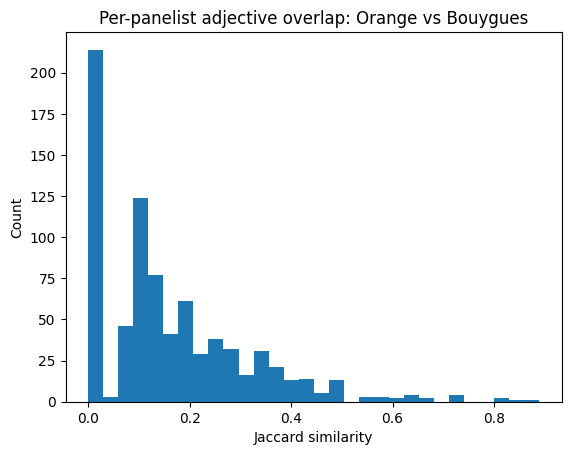

In [68]:
import matplotlib.pyplot as plt

resultats["jaccard_orange_bouygues"].hist(bins=30, grid=False)
plt.xlabel("Jaccard similarity")
plt.ylabel("Count")
plt.title("Per-panelist adjective overlap: Orange vs Bouygues")
plt.show()


In [69]:
import pandas as pd
from collections import Counter

top_n = 20

print("=== TOP ORANGE ADJECTIVES ===")
print(pd.Series(orange_counts).sort_values(ascending=False).head(top_n).to_string())

print("\n=== TOP BOUYGUES ADJECTIVES ===")
print(pd.Series(bouygues_counts).sort_values(ascending=False).head(top_n).to_string())


=== TOP ORANGE ADJECTIVES ===
fiable         484
simple         329
positif        242
humaine        170
classique      125
bonne          123
claire         108
chaleureux     107
original       102
positive        93
plus            87
clair           83
concret         72
efficace        65
chaleureuse     63
directe         60
originale       56
bien            55
direct          55
proche          51

=== TOP BOUYGUES ADJECTIVES ===
bizarre        179
original       169
fiable         154
positif        140
créative       121
originalité    105
originale      101
créatif        101
fort            88
différent       84
plus            73
clairement      65
bonne           64
simple          61
unique          61
marquante       57
concret         55
spécifique      50
chaleureux      50
forte           45


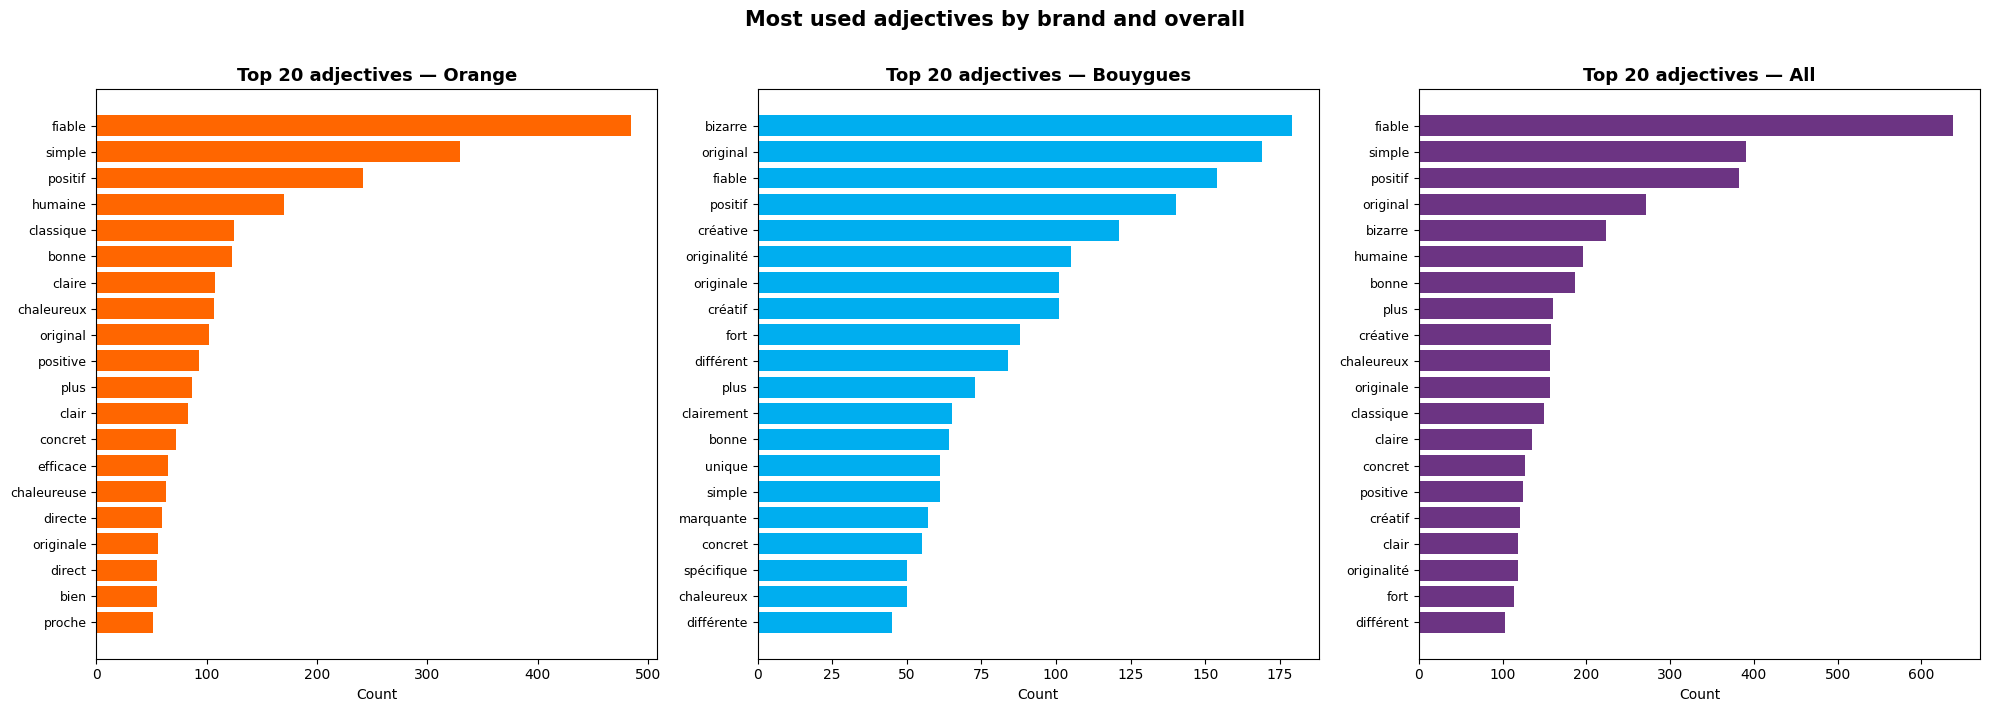

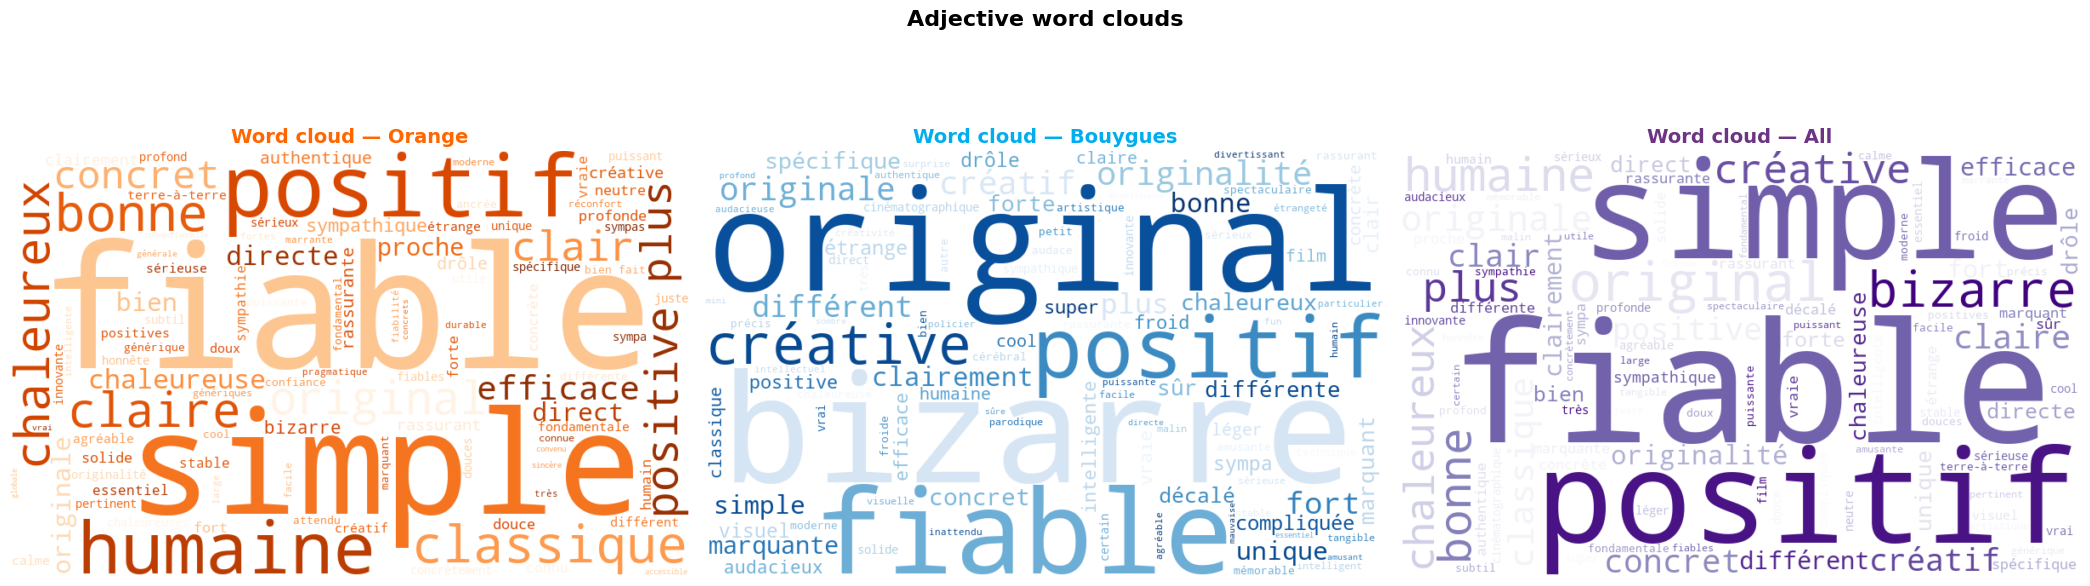

In [70]:
import pandas as pd
import numpy as np
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 1. Load data ──────────────────────────────────────────────────────────────
resultats = pd.read_csv("resultats_extraits_adj_g3.csv")

# ── 2. Tokenize adjective lists ───────────────────────────────────────────────
resultats["adj_orange_list"]   = resultats["adj_orange"].str.lower().str.split(r",\s*")
resultats["adj_bouygues_list"] = resultats["adj_bouygues"].str.lower().str.split(r",\s*")

def flatten(series):
    return [x.strip() for sub in series.dropna() for x in sub if x.strip()]

orange_tokens   = flatten(resultats["adj_orange_list"])
bouygues_tokens = flatten(resultats["adj_bouygues_list"])
all_tokens      = orange_tokens + bouygues_tokens

orange_counts   = Counter(orange_tokens)
bouygues_counts = Counter(bouygues_tokens)
all_counts      = Counter(all_tokens)

# ── 3. Bar chart — Top 20 adjectives per brand + overall ─────────────────────
TOP_N = 20

def top_df(counter, label):
    df = pd.DataFrame(counter.most_common(TOP_N), columns=["adjective", "count"])
    df["brand"] = label
    return df

df_orange   = top_df(orange_counts,   "Orange")
df_bouygues = top_df(bouygues_counts, "Bouygues")
df_all      = top_df(all_counts,      "All")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors = {"Orange": "#FF6600", "Bouygues": "#00AEEF", "All": "#6C3483"}

for ax, df in zip(axes, [df_orange, df_bouygues, df_all]):
    brand = df["brand"].iloc[0]
    ax.barh(df["adjective"][::-1], df["count"][::-1], color=colors[brand])
    ax.set_title(f"Top {TOP_N} adjectives — {brand}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Count")
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Most used adjectives by brand and overall", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("top_adjectives_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Word clouds ─────────────────────────────────────────────────────────────
wc_configs = [
    ("Orange",   orange_counts,   "#FF6600", "Oranges"),
    ("Bouygues", bouygues_counts, "#00AEEF", "Blues"),
    ("All",      all_counts,      "#6C3483", "Purples"),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (title, counts, color, cmap) in zip(axes, wc_configs):
    wc = WordCloud(
        width=800, height=500,
        background_color="white",
        colormap=cmap,
        max_words=100,
        prefer_horizontal=0.85,
    ).generate_from_frequencies(counts)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Word cloud — {title}", fontsize=14, fontweight="bold", color=color)

plt.suptitle("Adjective word clouds", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("wordclouds_adjectives.png", dpi=150, bbox_inches="tight")
plt.show()


In [71]:
orange_only_adjs = set(orange_counts.keys()) - set(bouygues_counts.keys())
bouygues_only_adjs = set(bouygues_counts.keys()) - set(orange_counts.keys())
shared_adjs = set(orange_counts.keys()) & set(bouygues_counts.keys())

print(f"Shared adjectives:        {len(shared_adjs)}")
print(f"Orange-only adjectives:   {len(orange_only_adjs)}")
print(f"Bouygues-only adjectives: {len(bouygues_only_adjs)}")

print("\nTop Orange-only:", sorted(orange_only_adjs, key=lambda x: -orange_counts[x])[:15])
print("Top Bouygues-only:", sorted(bouygues_only_adjs, key=lambda x: -bouygues_counts[x])[:15])


Shared adjectives:        303
Orange-only adjectives:   215
Bouygues-only adjectives: 258

Top Orange-only: ['connu', 'générale', 'convenu', 'tranquillité', 'orange', 'diffus', 'plus authentique', 'simples', 'sécurité', 'plus humaine', 'petites', 'justesse', 'percutant', 'profondes', 'réconfortant']
Top Bouygues-only: ['audace', 'cérébral', 'parodique', 'visuelle', 'étrangeté', 'policier', 'intellectuel', 'lot', 'cinéma', 'magique', 'mini-film', 'paradoxalement', 'marrant', 'exagérée', 'distant']


In [72]:
print("=== AGREEMENT HUMAN vs AGENT ===")
print(f"Overall agreement: {agreement:.2%}")

print("\n=== ADJECTIVE OVERLAP BY PREFERENCE ===")
print(group_stats.to_string(index=False))


=== AGREEMENT HUMAN vs AGENT ===
Overall agreement: 27.62%

=== ADJECTIVE OVERLAP BY PREFERENCE ===
 prefers_bouygues  n_overlap  n_orange_only  n_bouygues_only  jaccard_orange_bouygues
            False   2.000000       2.500000         1.000000                 0.285714
             True   1.468672       4.422306         3.862155                 0.159178


In [73]:
print(f"Cosine similarity (Orange vs Bouygues adj distributions): {cosine_sim:.4f}")
print(f"Jensen-Shannon divergence:                                 {js_div:.4f}")
print(f"KL(Orange || Bouygues):                                    {kl_orange_to_bouygues:.4f}")
print(f"KL(Bouygues || Orange):                                    {kl_bouygues_to_orange:.4f}")
print(f"Shannon entropy Orange:                                    {h_orange:.4f}")
print(f"Shannon entropy Bouygues:                                  {h_bouygues:.4f}")


Cosine similarity (Orange vs Bouygues adj distributions): 0.6394
Jensen-Shannon divergence:                                 0.5411
KL(Orange || Bouygues):                                    inf
KL(Bouygues || Orange):                                    inf
Shannon entropy Orange:                                    6.8085
Shannon entropy Bouygues:                                  7.3777


### Interviews' adjectives


In [74]:
bouygues_cols = [c for c in panel.columns if c.startswith("Q_bouygues_")]
orange_cols = [c for c in panel.columns if c.startswith("Q_orange_")]
comparaison_cols = [c for c in panel.columns if c.startswith("Q_comparaison_")]

print("Bouygues questions:", bouygues_cols)
print("Orange questions:", orange_cols)
print("Comparaison questions:", comparaison_cols)

Bouygues questions: ['Q_bouygues_reactions_spontanees_1', 'Q_bouygues_memorisation_1', 'Q_bouygues_caractere_distinctif_1', 'Q_bouygues_attractivite_1', 'Q_bouygues_attractivite_2', 'Q_bouygues_resonance_emotionnelle_1', 'Q_bouygues_image_1', 'Q_bouygues_intention_achat_1']
Orange questions: ['Q_orange_reactions_spontanees_1', 'Q_orange_memorisation_1', 'Q_orange_caractere_distinctif_1', 'Q_orange_attractivite_1', 'Q_orange_attractivite_2', 'Q_orange_resonance_emotionnelle_1', 'Q_orange_image_1', 'Q_orange_intention_achat_1']
Comparaison questions: ['Q_comparaison_1', 'Q_comparaison_2', 'Q_comparaison_3', 'Q_comparaison_4', 'Q_comparaison_5', 'Q_comparaison_6']


In [75]:
!python -m spacy download fr_core_news_lg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 MB 1.8 MB/s  0:05:220:00:0100:11
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_lg')


In [76]:
import spacy
nlp = spacy.load("fr_core_news_lg")


In [77]:
def extract_adjs(text):
    if not isinstance(text, str):
        return []
    return [t.lemma_.lower() for t in nlp(text) if t.pos_ == "ADJ"]

for col in bouygues_cols + orange_cols + comparaison_cols:
    panel[col + "_adjs"] = panel[col].apply(extract_adjs)


In [78]:
panel["adj_bouygues_full"] = panel[[c + "_adjs" for c in bouygues_cols]].apply(
    lambda row: [adj for adjs in row for adj in adjs], axis=1
)

panel["adj_orange_full"] = panel[[c + "_adjs" for c in orange_cols]].apply(
    lambda row: [adj for adjs in row for adj in adjs], axis=1
)


In [79]:
panel[["panelist_id", "adj_orange_full", "adj_bouygues_full"]].head(5)


,panelist_id,adj_orange_full,adj_bouygues_full
0,67b0d135d362f5886c2e5cfe,"[vrai, petit, bricol, petit, clair, direct, cl...","[marrant, policier, décaler, premier, original..."
1,67b0d12ed362f5886c2e5b9c,"[sympa, tout, petit, facile, stupide, général,...","[marrant, policier, chang, plein, différent, t..."
2,67b0d12bd362f5886c2e5b09,"[vrai, petit, tout, direct, simple, bizarre, c...","[marrant, original, policier, surprenant, diff..."
3,67b0d127d362f5886c2e5a4a,"[normal, tout, petit, vrai, jeune, habituel, o...","[compris, compliqué, grand, vieux, gros, bizar..."
4,67b0d12cd362f5886c2e5b4a,"[classique, petit, simple, compliqué, humorist...","[marrant, original, chang, décaler, entier, fa..."


In [80]:
panel[["panelist_id"] + [c + "_adjs" for c in bouygues_cols + orange_cols + comparaison_cols] + ["adj_bouygues_full", "adj_orange_full"]].to_csv("panel_adjectives_extracted.csv", index=False)


In [81]:
panel.head()

,panelist_id,interview_number,timestamp,age,children,csp,education,gender,income_level,location.city_size,...,Q_orange_image_1_adjs,Q_orange_intention_achat_1_adjs,Q_comparaison_1_adjs,Q_comparaison_2_adjs,Q_comparaison_3_adjs,Q_comparaison_4_adjs,Q_comparaison_5_adjs,Q_comparaison_6_adjs,adj_bouygues_full,adj_orange_full
0,67b0d135d362f5886c2e5cfe,1,2025-11-15T21:16:58.828353,28,NaN,Ouvriers,Secondary,Male,22000,Large city,...,"[solide, fiable, sérieux, paternel, fun, jeune...","[important, pourrir, fiable]","[marrant, original, petit, sympa, efficace, ba...",[absurde],"[différent, habituel]","[rir, simple, positif, fort, rationnel]","[marrant, beau]","[tout, important, direct, précis, spécifique, ...","[marrant, policier, décaler, premier, original...","[vrai, petit, bricol, petit, clair, direct, cl..."
1,67b0d12ed362f5886c2e5b9c,2,2025-11-15T21:17:04.626005,23,NaN,Employés,Secondary,Male,15000,Small village,...,"[fiable, solide, rassurant, décaler, sérieux, ...","[fiable, plein]","[difficile, différent, surprenant, divertissant]","[facile, autre]","[tout, policier, vrai, créatif]","[fort, diffus]","[marrant, fiable, direct, rassurant]",[clair],"[marrant, policier, chang, plein, différent, t...","[sympa, tout, petit, facile, stupide, général,..."
2,67b0d12bd362f5886c2e5b09,3,2025-11-15T21:17:09.971836,47,"17, 14, 11",Ouvriers,Secondary,Male,27000,Small village,...,"[grand, fiable, rassurant, autre, solide, hist...","[fiable, important, fiable]","[simple, propre]","[bizarre, policier, petit]",[original],"[fort, positif, vrai, vrai]","[principal, amusant]","[fiable, clair, direct, simple]","[marrant, original, policier, surprenant, diff...","[vrai, petit, tout, direct, simple, bizarre, c..."
3,67b0d127d362f5886c2e5a4a,4,2025-11-15T21:17:18.211898,68,"38, 35",Retraités,No formal education,Male,21000,Small village,...,"[solide, ancien, proche]","[fiable, ancien]","[cell, simple, direct]","[marquant, bizarre, important]","[sûr, différent, bon, différent]","[positif, autre, perplexe, grand]",[],[],"[compris, compliqué, grand, vieux, gros, bizar...","[normal, tout, petit, vrai, jeune, habituel, o..."
4,67b0d12cd362f5886c2e5b4a,5,2025-11-15T21:17:17.641665,29,NaN,Cadres (y compris commerçants & artisans),Higher education,Female,45000,Large city,...,"[sûr, solide, sérieux, rassurant, fun]","[crucial, fiable, lourd, absolu]",[],"[unique, efficace, autre, même]","[narratif, classique]","[positif, immédiat, profond, divertissant]","[difficile, spécifique, fondamental, professio...","[global, bon, central, bon, large]","[marrant, original, chang, décaler, entier, fa...","[classique, petit, simple, compliqué, humorist..."
